# FraudLens: Baseline models

Compares the three baseline runs logged by `fraudlens train` (Phase 4) on the **validation**
split. This notebook does not train anything: it reads the runs and models from MLflow and calls
the same `src/fraudlens` functions the CLI uses, so there is one implementation of every metric.

**Prerequisites:** MLflow running (`docker compose --profile train up -d mlflow`) and
`uv run fraudlens train` completed. The test set is not loaded.

In [1]:
%matplotlib inline
import mlflow
import pandas as pd
from IPython.display import display

from fraudlens.config import get_env, load_config
from fraudlens.models.estimators import feature_importance
from fraudlens.models.evaluate import (
    evaluate,
    plot_confusion,
    plot_cost_curve,
    plot_feature_importance,
    plot_pr_comparison,
)
from fraudlens.models.train import DISPLAY_NAMES, configure_mlflow, load_split_data

config = load_config()
configure_mlflow(get_env().mlflow_tracking_uri, config.training.experiment_name)
FP_COST = config.costs.false_positive_cost

runs = mlflow.search_runs(
    experiment_names=[config.training.experiment_name],
    filter_string="tags.stage = 'baseline'",
    order_by=["metrics.val_pr_auc DESC"],
)
runs = runs.drop_duplicates("tags.model_family")  # latest run per model family
print(f"{len(runs)} baseline runs found")

C:\Users\yashr\FraudLens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3 baseline runs found


## 1. Comparison table (validation, cost-optimal threshold)

In [2]:
cols = {
    "metrics.val_pr_auc": "PR-AUC",
    "metrics.val_roc_auc": "ROC-AUC",
    "metrics.val_threshold": "threshold",
    "metrics.val_precision": "precision",
    "metrics.val_recall": "recall",
    "metrics.val_alerts": "alerts",
    "metrics.val_cost": "cost ($)",
    "metrics.val_cost_saving": "saving vs flag-nothing",
    "metrics.val_f1max_cost": "cost at F1-max ($)",
    "metrics.train_pr_auc": "train PR-AUC",
}
table = runs.set_index(runs["tags.model_family"].map(DISPLAY_NAMES))[list(cols)].rename(
    columns=cols
)
table.index.name = "model"
display(
    table.style.format(
        {
            "PR-AUC": "{:.3f}",
            "ROC-AUC": "{:.4f}",
            "threshold": "{:.3f}",
            "precision": "{:.2f}",
            "recall": "{:.2f}",
            "alerts": "{:,.0f}",
            "cost ($)": "${:,.0f}",
            "saving vs flag-nothing": "{:.1%}",
            "cost at F1-max ($)": "${:,.0f}",
            "train PR-AUC": "{:.3f}",
        }
    )
)
print(f"Flag-nothing cost on validation: ${runs['metrics.val_cost_flag_nothing'].iloc[0]:,.0f}")

,PR-AUC,ROC-AUC,threshold,precision,recall,alerts,cost ($),saving vs flag-nothing,cost at F1-max ($),train PR-AUC
model,,,,,,,,,,
LightGBM,0.984,0.9996,0.364,0.91,0.97,"1,011","$3,015",99.4%,"$12,894",1.000
XGBoost,0.982,0.9996,0.489,0.86,0.97,"1,075","$3,216",99.4%,"$9,866",0.999
Logistic regression,0.421,0.9877,0.594,0.28,0.92,"3,088","$19,904",96.1%,"$68,074",0.406


Flag-nothing cost on validation: $508,489


**Reading the table:**

- **LightGBM is best** on PR-AUC (0.984) and on cost ($3,015, against $508,489 if nothing were
  flagged: 99.4% of the possible loss avoided). XGBoost is close behind.
- **Logistic regression lags far behind on PR-AUC (0.42)** even though its ROC-AUC (0.988) looks
  excellent. With 0.6% fraud, ROC-AUC is dominated by the huge number of easy legitimate
  transactions; PR-AUC measures what matters, how clean the alert queue is at each recall.
- **The F1-optimal threshold would cost 3-4x more** for the tree models: it raises the bar to
  avoid false alarms, which are cheap ($5 each), and in exchange misses fraud, which is
  expensive (the full amount).
- **Train PR-AUC of 1.000 for LightGBM** means the default 63-leaf, 400-tree model memorises the
  training set. Validation is still 0.984, but Phase 5 tuning should look for a more regular model.

## 2. Validation scores from the logged models

In [3]:
data = load_split_data(config)
models, scores = {}, {}
for _, run in runs.iterrows():
    name = run["tags.model_family"]
    models[name] = mlflow.sklearn.load_model(f"runs:/{run['run_id']}/model")
    scores[name] = models[name].predict_proba(data.X_val)[:, 1]
evals = {n: evaluate(data.y_val, s, data.amt_val, FP_COST) for n, s in scores.items()}
for n, ev in evals.items():  # the loaded models must reproduce the logged metrics exactly
    assert (
        abs(ev.pr_auc - runs.loc[runs["tags.model_family"] == n, "metrics.val_pr_auc"].iloc[0])
        < 1e-9
    )
print("Loaded models reproduce the logged validation metrics.")

Loaded models reproduce the logged validation metrics.


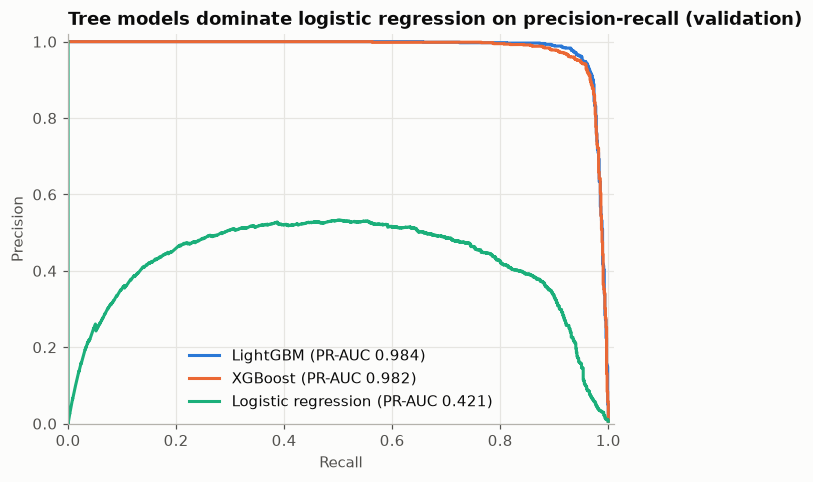

In [4]:
plot_pr_comparison(
    {DISPLAY_NAMES[n]: (data.y_val, s) for n, s in scores.items()},
    "Tree models dominate logistic regression on precision-recall (validation)",
)

## 3. Why the threshold is chosen by cost, not F1

,threshold,alerts,fraud caught,fraud missed,false alarms,missed fraud ($),review cost ($),total cost ($),F1
rule,,,,,,,,,
cost-optimal,0.364,1011,920,28,91,"$2,560",$455,"$3,015",0.939
F1-optimal,0.932,897,882,66,15,"$12,819",$75,"$12,894",0.956


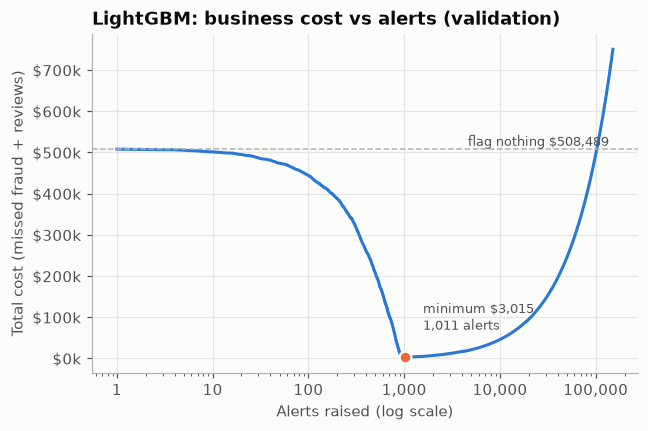

In [5]:
best = runs["tags.model_family"].iloc[0]
ev = evals[best]
rows = []
for label_, pt in [("cost-optimal", ev.cost_point), ("F1-optimal", ev.f1_point)]:
    rows.append(
        {
            "rule": label_,
            "threshold": pt.threshold,
            "alerts": pt.alerts,
            "fraud caught": pt.tp,
            "fraud missed": pt.fn,
            "false alarms": pt.fp,
            "missed fraud ($)": pt.fraud_amount_missed,
            "review cost ($)": pt.fp * FP_COST,
            "total cost ($)": pt.total_cost,
            "F1": pt.f1,
        }
    )
display(
    pd.DataFrame(rows)
    .set_index("rule")
    .style.format(
        {
            "threshold": "{:.3f}",
            "missed fraud ($)": "${:,.0f}",
            "review cost ($)": "${:,.0f}",
            "total cost ($)": "${:,.0f}",
            "F1": "{:.3f}",
        }
    )
)
plot_cost_curve(
    data.y_val,
    scores[best],
    data.amt_val,
    FP_COST,
    ev,
    f"{DISPLAY_NAMES[best]}: business cost vs alerts (validation)",
)

**Takeaway:** a missed fraud costs on average about **$530** (the mean fraud amount in training), while a false
alarm costs **$5** of analyst time, so each missed fraud is worth roughly 100 false alarms. The
F1 score treats both errors as equally bad and therefore picks a stricter threshold that misses
more fraud. Choosing the threshold that minimises total cost raises a few more alerts and saves
several thousand dollars on two months of validation data.

## 4. Best model: confusion matrix and feature importance

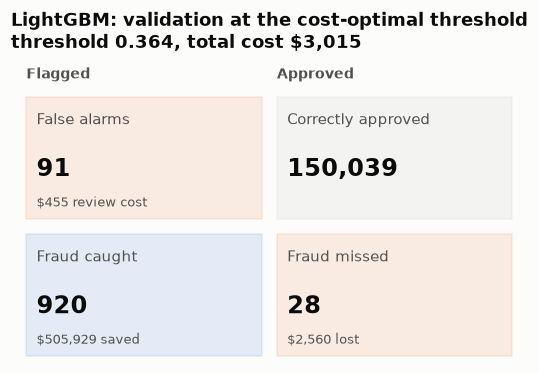

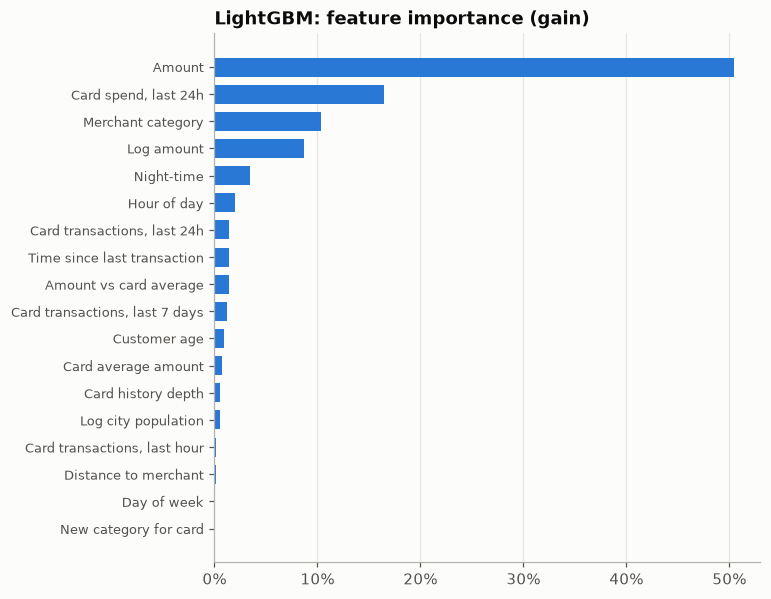

In [6]:
display(
    plot_confusion(
        ev.cost_point, f"{DISPLAY_NAMES[best]}: validation at the cost-optimal threshold"
    )
)
display(
    plot_feature_importance(
        feature_importance(models[best]), f"{DISPLAY_NAMES[best]}: feature importance (gain)"
    )
)

**Takeaway:** at the cost-optimal threshold the best model catches **920 of 948 frauds (97%)**
with **91 false alarms** among 151,078 transactions. The importance chart matches the EDA:
amount, 24-hour card spend, merchant category and time of day carry most of the signal, and
distance to the merchant is close to zero, as expected for this simulator. Gain importance shows
what the model uses overall; Phase 7 adds SHAP to explain individual decisions.

## Summary

| | |
|---|---|
| Best baseline | LightGBM: PR-AUC 0.984, cost $3,015 on validation |
| Why not accuracy | 99.4% accuracy is achievable by flagging nothing |
| Why PR-AUC, not ROC-AUC | logistic regression: ROC-AUC 0.988 but PR-AUC 0.42 |
| Why cost, not F1 | the F1 threshold costs 4.3x more for LightGBM |
| Next | Phase 5: tune XGBoost and LightGBM on Kaggle; the test set is still untouched |